In [1]:
!pip install opencv-python pillow matplotlib

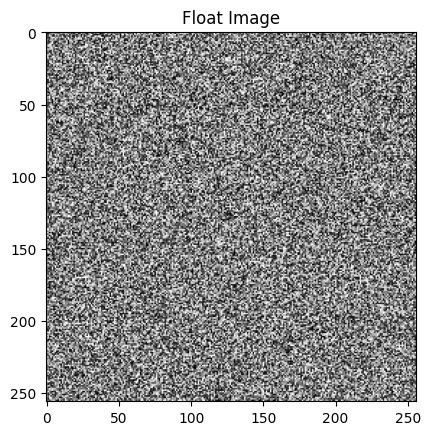

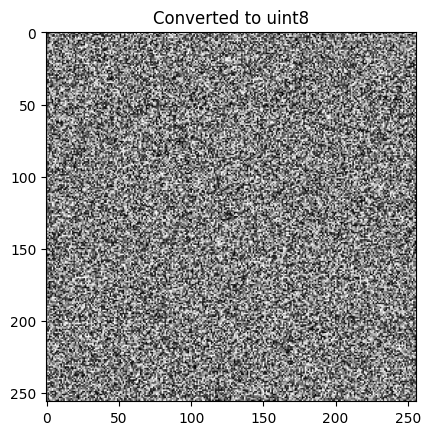

In [2]:
import numpy as np
import matplotlib.pyplot as plt

img = np.random.rand(256,256)

plt.imshow(img, cmap='gray')
plt.title("Float Image")
plt.show()

img_uint8 = (img * 255).astype(np.uint8)

plt.imshow(img_uint8, cmap='gray')
plt.title("Converted to uint8")
plt.show()

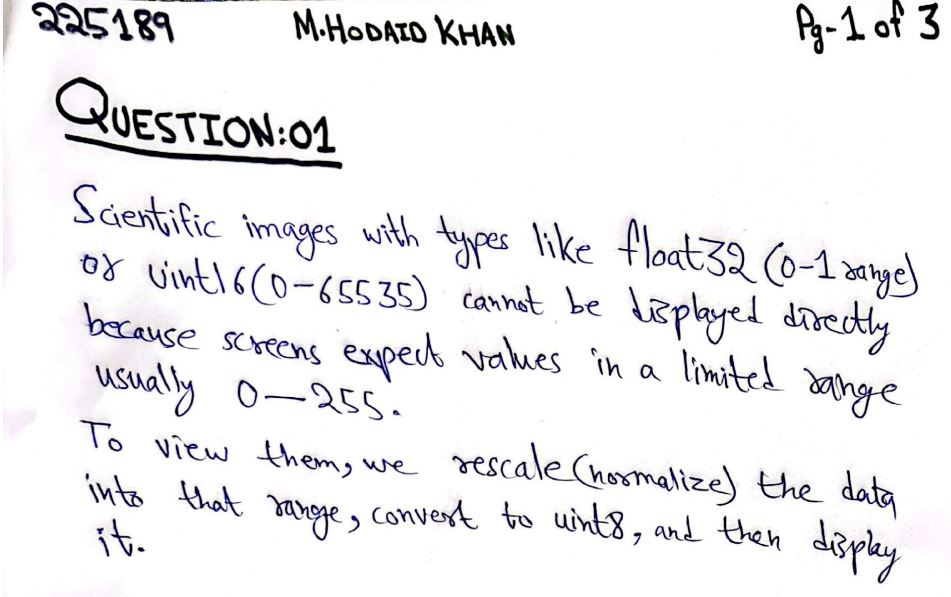

In [5]:
from PIL import Image
from PIL.ExifTags import TAGS

image = Image.open("cover.png")

print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

exif_data = image._getexif()

if exif_data:
    for tag, value in exif_data.items():
        print(TAGS.get(tag), value)

Format: PNG
Size: (949, 508)
Mode: RGBA


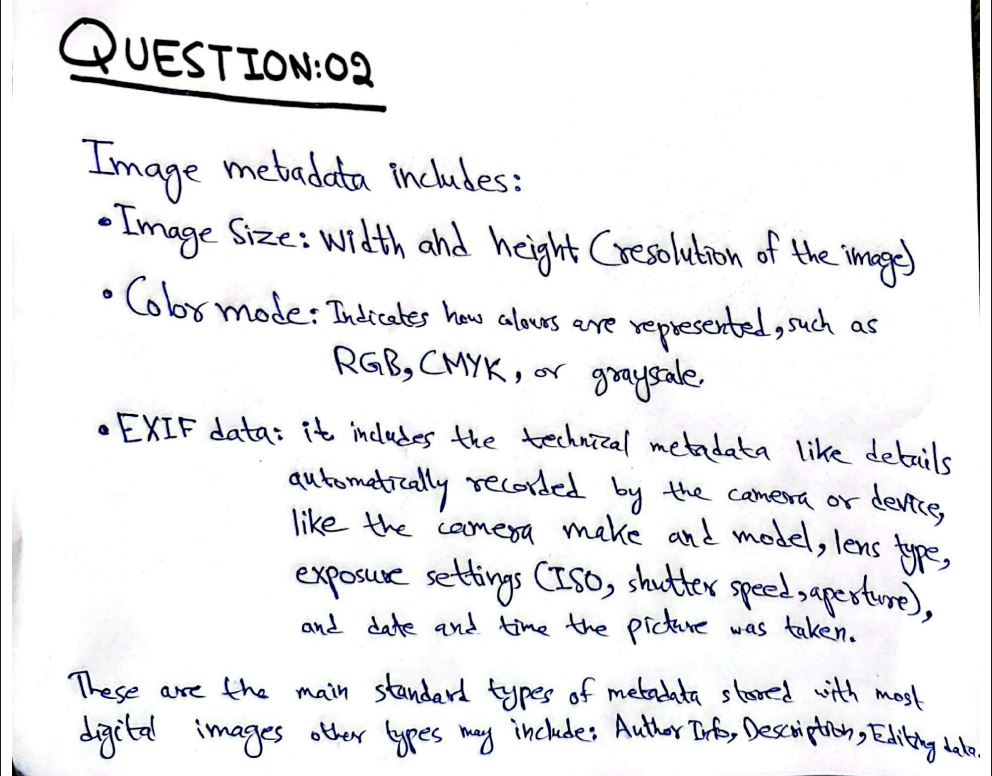

In [6]:
import cv2

img = cv2.imread("cover.png")

nearest = cv2.resize(img, (300,300), interpolation=cv2.INTER_NEAREST)
area = cv2.resize(img, (300,300), interpolation=cv2.INTER_AREA)
lanczos = cv2.resize(img, (300,300), interpolation=cv2.INTER_LANCZOS4)

cv2.imwrite("nearest.png", nearest)
cv2.imwrite("area.png", area)
cv2.imwrite("lanczos.png", lanczos)

True

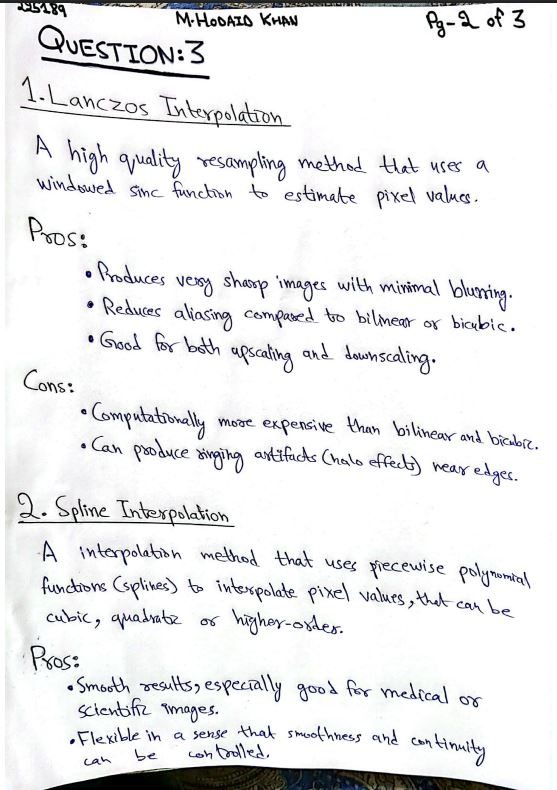

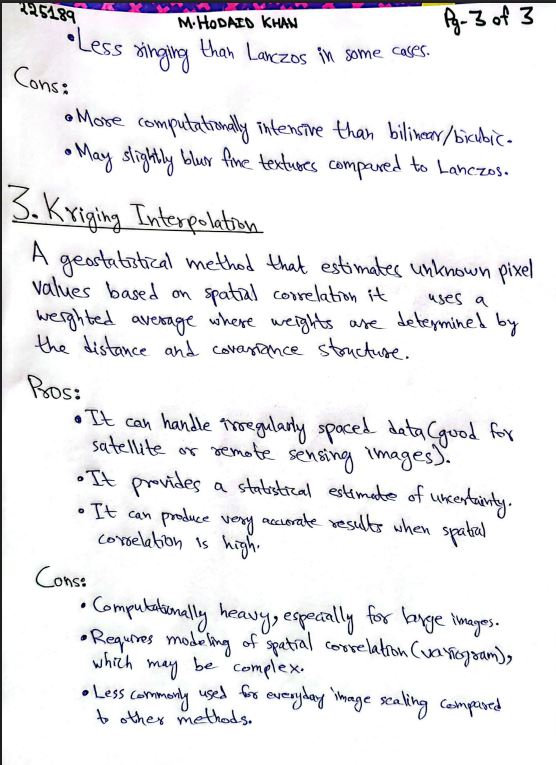

In [7]:
import cv2

cover = cv2.imread("cover.png")
secret = cv2.imread("secret.png")

secret = cv2.resize(secret, (cover.shape[1], cover.shape[0]))

stego = (cover & 254) | (secret >> 7)

cv2.imwrite("stego.png", stego)

extracted = (stego & 1) * 255
cv2.imwrite("extracted.png", extracted)

True

(np.float64(-0.5), np.float64(948.5), np.float64(507.5), np.float64(-0.5))

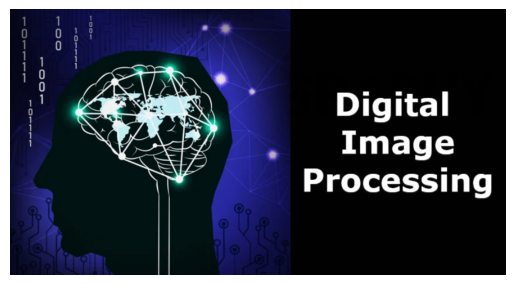

In [8]:
from matplotlib import pyplot as plt
import cv2

img = cv2.imread("stego.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')